# CS4168 Data Mining Project (AY 2025/2026)

This notebook covers:
1. EDA
2. Clustering (KMeans + DBSCAN)
3. Classification (predicting popularity category)
4. Regression (predicting popularity score)

Dataset used: `tracks2026.csv`

In [1]:
# If needed, uncomment to install packages
# !pip install pandas numpy matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('tracks2026.csv')

# Make boolean columns numeric for smoother preprocessing in sklearn pipelines.
# (SimpleImputer with median does not accept raw bool dtype in some setups.)
bool_cols = df.select_dtypes(include=['bool']).columns
for c in bool_cols:
    df[c] = df[c].astype(int)

print('Shape:', df.shape)
print('Converted boolean columns:', list(bool_cols))
df.head()

Shape: (2000, 17)
Converted boolean columns: ['explicit']


,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


## 1) Exploratory Data Analysis (EDA)

This is the "get to know the data" step. I am checking:
- what each column looks like,
- where values are missing,
- and which features seem related to popularity or genre.

These observations will guide what preprocessing and models make sense later.

In [3]:
# Check data types first so we know which columns are numeric vs categorical.
print('\nData types:\n')
print(df.dtypes)

# Missing values matter because they can bias results or break models if ignored.
print('\nMissing values:\n')
print(df.isna().sum())

# Quick statistical overview: ranges, central tendency, spread, etc.
print('\nSummary statistics:\n')
display(df.describe(include='all').transpose())


Data types:

track_id                str
popularity          float64
duration_ms           int64
explicit              int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

Missing values:

track_id             0
popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            39
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

Summary statistics:



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,2000,1968,43mHckutQvJr49nT0UvRxy,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,1960.0,NaN,NaN,NaN,39.805102,29.245904,0.0,1.75,45.0,65.0,100.0
duration_ms,2000.0,NaN,NaN,NaN,217806.433,56804.759189,60000.0,181210.0,211346.0,246069.75,561133.0
explicit,2000.0,NaN,NaN,NaN,0.1115,0.314829,0.0,0.0,0.0,0.0,1.0
danceability,1960.0,NaN,NaN,NaN,0.635897,0.138298,0.185,0.548,0.646,0.738,0.953
energy,1960.0,NaN,NaN,NaN,0.632489,0.189087,0.0909,0.50775,0.644,0.78,0.996
key,2000.0,NaN,NaN,NaN,5.2955,3.567148,0.0,2.0,5.0,8.0,11.0
loudness,1961.0,NaN,NaN,NaN,400.575884,18065.717039,-21.089,-8.988,-6.924,-5.39,800000.0
mode,2000.0,NaN,NaN,NaN,0.6375,0.480842,0.0,0.0,1.0,1.0,1.0
speechiness,2000.0,NaN,NaN,NaN,0.078466,0.076223,0.0221,0.034475,0.0475,0.08495,0.515


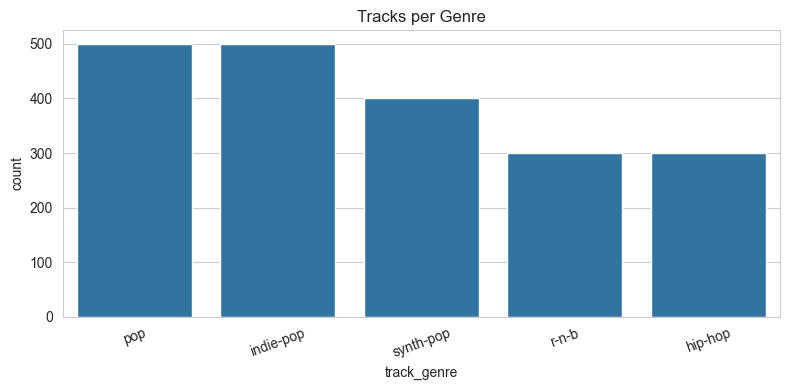

In [4]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='track_genre', order=df['track_genre'].value_counts().index)
plt.title('Tracks per Genre')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

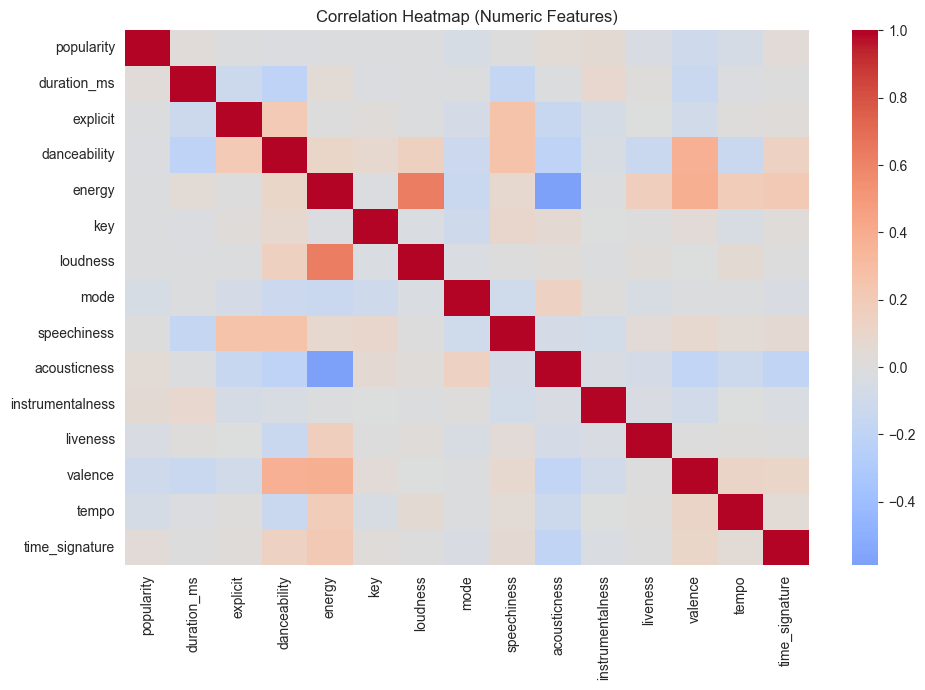

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

## 2) Clustering (Descriptive Analytics)

Goal: group songs by similar audio characteristics without using labels.

I drop `track_genre` for clustering because it is the known label and would leak the answer. After clustering, I compare discovered groups with genres to see if structure is meaningful.

In [6]:
# Keep a clean copy and remove the known label for unsupervised learning.
cluster_df = df.drop(columns=['track_genre']).copy()

# track_id is an identifier, not a behavioral feature, so we exclude it.
target_like_cols = ['track_id']
features_for_clustering = [c for c in cluster_df.columns if c not in target_like_cols]

X_cluster = cluster_df[features_for_clustering]

# Split columns by type so each gets suitable preprocessing.
numeric_features = X_cluster.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_cluster.columns if c not in numeric_features]

# Median/mode imputation handles missing values; scaling helps distance-based methods.
preprocess_cluster = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ]
)

Xc = preprocess_cluster.fit_transform(X_cluster)
print('Transformed clustering shape:', Xc.shape)

Transformed clustering shape: (2000, 15)


In [7]:
# Try at least two values of k (required by spec) and compare quality.
k_values = [3, 5]
kmeans_results = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(Xc)

    # Silhouette score: higher usually means tighter, better-separated clusters.
    sil = silhouette_score(Xc, labels)
    kmeans_results[k] = {'model': km, 'labels': labels, 'silhouette': sil}
    print(f'KMeans k={k}: silhouette={sil:.4f}')

KMeans k=3: silhouette=0.1388


KMeans k=5: silhouette=0.1476


In [8]:
dbscan = DBSCAN(eps=1.2, min_samples=8)
db_labels = dbscan.fit_predict(Xc)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print('DBSCAN clusters (excluding noise):', n_clusters_db)
print('DBSCAN noise points:', (db_labels == -1).sum())

if n_clusters_db > 1:
    db_sil = silhouette_score(Xc, db_labels)
    print(f'DBSCAN silhouette={db_sil:.4f}')
else:
    print('DBSCAN silhouette not computed (needs >1 cluster).')

DBSCAN clusters (excluding noise): 6
DBSCAN noise points: 1932
DBSCAN silhouette=-0.2060


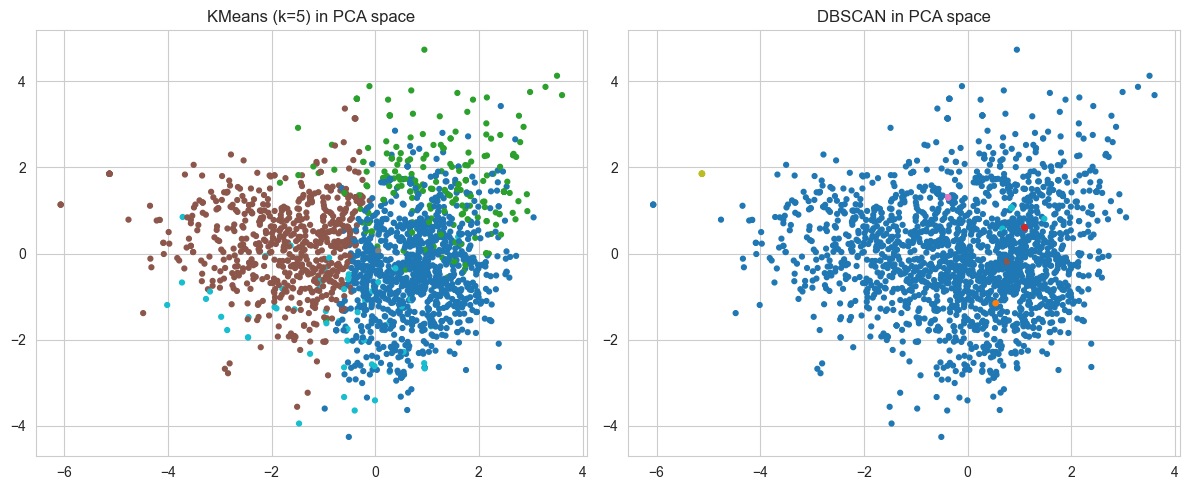

In [9]:
# 2D PCA visualisations
pca = PCA(n_components=2, random_state=42)
Xc_2d = pca.fit_transform(Xc)

best_k = max(kmeans_results, key=lambda k: kmeans_results[k]['silhouette'])
best_k_labels = kmeans_results[best_k]['labels']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(Xc_2d[:,0], Xc_2d[:,1], c=best_k_labels, s=12, cmap='tab10')
ax[0].set_title(f'KMeans (k={best_k}) in PCA space')

ax[1].scatter(Xc_2d[:,0], Xc_2d[:,1], c=db_labels, s=12, cmap='tab10')
ax[1].set_title('DBSCAN in PCA space')

plt.tight_layout()
plt.show()

In [10]:
# Optional: compare clustering with known genres (not used in clustering input)
genre_codes = df['track_genre'].astype('category').cat.codes
alignment = pd.crosstab(best_k_labels, df['track_genre'])
display(alignment)

track_genre,hip-hop,indie-pop,pop,r-n-b,synth-pop
row_0,,,,,
0,167,202,263,178,291
1,99,52,37,16,15
2,33,229,194,105,66
3,0,0,1,0,0
4,1,17,5,1,28


## 3) Classification (Predicting Popularity Category)

Here I convert popularity into a simple high-vs-low target using the median.

Why this helps: predicting an exact score can be noisy, but high/low classes are often easier to model and interpret. I also remove original `popularity` from features to avoid target leakage.

In [11]:
clf_df = df.copy()

# Median split required by the spec.
median_popularity = clf_df['popularity'].median(skipna=True)

# Remove rows where target is missing, then create binary label.
clf_df = clf_df.dropna(subset=['popularity']).copy()
clf_df['popularity_binary'] = (clf_df['popularity'] > median_popularity).astype(int)

# Remove original popularity so the model cannot "cheat".
X_clf = clf_df.drop(columns=['popularity', 'popularity_binary'])
y_clf = clf_df['popularity_binary']

num_cols_clf = X_clf.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_clf = [c for c in X_clf.columns if c not in num_cols_clf]

# Same clean preprocessing logic inside a pipeline.
preprocess_clf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_clf),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_clf)
    ]
)

# Stratify keeps class proportions similar in train and test sets.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print('Classification median popularity:', median_popularity)
print('Class balance:\n', y_clf.value_counts(normalize=True))

Classification median popularity: 45.0
Class balance:
 popularity_binary
0    0.507143
1    0.492857
Name: proportion, dtype: float64


In [12]:
# Compare two different modeling styles:
# - Logistic Regression: simple and interpretable baseline
# - Random Forest: nonlinear model that can capture interactions
clf_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'RandomForestClassifier': RandomForestClassifier(random_state=42)
}

clf_results = []
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in clf_models.items():
    pipe = Pipeline([
        ('preprocess', preprocess_clf),
        ('model', model)
    ])

    # Cross-validation happens on the training set only.
    # This gives a more reliable estimate than a single split.
    cv_f1 = cross_val_score(pipe, X_train_c, y_train_c, cv=cv_clf, scoring='f1')

    pipe.fit(X_train_c, y_train_c)
    preds = pipe.predict(X_test_c)

    # Accuracy gives overall correctness; F1 balances precision/recall.
    acc = accuracy_score(y_test_c, preds)
    f1 = f1_score(y_test_c, preds)

    clf_results.append((name, acc, f1, cv_f1.mean(), cv_f1.std(), pipe))
    print(f'{name}: CV F1={cv_f1.mean():.4f} (+/- {cv_f1.std():.4f}), test accuracy={acc:.4f}, test f1={f1:.4f}')

# Use CV F1 as primary selection metric, then confirm on test performance.
best_clf = sorted(clf_results, key=lambda x: x[3], reverse=True)[0]
print('\nBest classification model (by CV F1):', best_clf[0])

LogisticRegression: CV F1=0.6363 (+/- 0.0255), test accuracy=0.6301, test f1=0.6366


RandomForestClassifier: CV F1=0.7119 (+/- 0.0274), test accuracy=0.7449, test f1=0.7340

Best classification model (by CV F1): RandomForestClassifier


In [13]:
best_name, test_acc, test_f1, cv_mean, cv_std, best_clf_pipe = best_clf
best_preds = best_clf_pipe.predict(X_test_c)

print(f'Chosen classifier: {best_name}')
print(f'CV F1: {cv_mean:.4f} (+/- {cv_std:.4f})')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1: {test_f1:.4f}')
print('\nDetailed classification report:')
print(classification_report(y_test_c, best_preds, digits=4))

Chosen classifier: RandomForestClassifier
CV F1: 0.7119 (+/- 0.0274)
Test Accuracy: 0.7449
Test F1: 0.7340

Detailed classification report:
              precision    recall  f1-score   support

           0     0.7368    0.7739    0.7549       199
           1     0.7541    0.7150    0.7340       193

    accuracy                         0.7449       392
   macro avg     0.7455    0.7444    0.7445       392
weighted avg     0.7453    0.7449    0.7446       392



## 4) Regression (Predicting Popularity Score)

Now I predict the original numeric popularity value directly.

This is usually harder than classification because the model must estimate an exact number, not just high vs low. I compare multiple regression models and choose based on error metrics.

In [14]:
reg_df = df.dropna(subset=['popularity']).copy()

X_reg = reg_df.drop(columns=['popularity'])
y_reg = reg_df['popularity']

num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_reg = [c for c in X_reg.columns if c not in num_cols_reg]

preprocess_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_reg),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_reg)
    ]
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [15]:
# Compare a simple linear model, regularized linear model, and nonlinear ensemble model.
reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForestRegressor': RandomForestRegressor(random_state=42)
}

reg_results = []
cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in reg_models.items():
    pipe = Pipeline([
        ('preprocess', preprocess_reg),
        ('model', model)
    ])

    # CV with negative RMSE is standard in sklearn; we convert it back to RMSE.
    cv_neg_rmse = cross_val_score(pipe, X_train_r, y_train_r, cv=cv_reg, scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_neg_rmse

    pipe.fit(X_train_r, y_train_r)
    preds = pipe.predict(X_test_r)

    # MAE: average absolute error, RMSE: penalizes larger mistakes, R2: explained variance.
    mae = mean_absolute_error(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    r2 = r2_score(y_test_r, preds)

    reg_results.append((name, mae, rmse, r2, cv_rmse.mean(), cv_rmse.std(), pipe))
    print(f'{name}: CV RMSE={cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f}), test MAE={mae:.4f}, test RMSE={rmse:.4f}, test R2={r2:.4f}')

# Pick the model with the lowest CV RMSE, then report test metrics.
best_reg = sorted(reg_results, key=lambda x: x[4])[0]
print('\nBest regression model (by CV RMSE):', best_reg[0])

LinearRegression: CV RMSE=28.7682 (+/- 0.8150), test MAE=25.0885, test RMSE=28.6267, test R2=0.0282


Ridge: CV RMSE=28.7793 (+/- 0.7753), test MAE=25.1168, test RMSE=28.5660, test R2=0.0323


RandomForestRegressor: CV RMSE=25.0717 (+/- 0.8848), test MAE=18.8818, test RMSE=24.7614, test R2=0.2729

Best regression model (by CV RMSE): RandomForestRegressor


## 5) Interpretation Notes (Write in Your Own Voice)

Use the prompts below right after running the notebook. Keep your answers specific to your numbers and plots.

### EDA (what the data is telling us)
- Which features looked most informative for popularity or genre?
- Were there obvious data quality issues (missing values, skew, outliers)?
- How did EDA influence your preprocessing choices?

### Clustering
- Which method gave the most meaningful grouping and why?
- For KMeans, why was your final `k` a better choice than the alternative?
- Did clusters align with `track_genre`, fully or only partly?
- If alignment was weak, what is a realistic reason (overlap between genres, noisy labels, feature limits)?

### Classification (high vs low popularity)
- Which model won on **CV F1** and did test performance support that choice?
- Why is F1 a sensible selection metric here?
- Mention one modelling decision that improved results and one that hurt results.

### Regression (exact popularity)
- Which model won on **CV RMSE** and how did it do on test RMSE/MAE/R2?
- What kinds of errors did the model seem to make?
- Explain clearly whether predicting exact popularity is harder than high/low prediction, using your metrics.

### Final reflection
- If you had more time, what one improvement would you try next (feature engineering, hyperparameter tuning, or model choice)?
- What is the main practical takeaway from this analysis?